In [104]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [105]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2132, 33]), y_train shape: torch.Size([2132, 1])
X_val shape: torch.Size([457, 33]), y_val shape: torch.Size([457, 1])
X_test shape: torch.Size([458, 33]), y_test shape: torch.Size([458, 1])


In [106]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
batch_size = 128

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

#### Hyperparameters

In [108]:
epochs = 500
learning_rate = 0.01
dropout = 0.3
batch_norm = True
l2_lambda = 1e-4
grad_clip = False

In [109]:
def pipeline(
        model, 
        epochs=50, 
        verbose=True, 
        early_stopping=False, 
        patience=10, 
        grad_clip=True
):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping, 
        patience=patience, 
        grad_clip=grad_clip
    )
    test_model(model, X_test, y_test)
    plot_loss(train_losses, val_losses, log=True)

### Linear Regression

In [110]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


========= Model Evaluation =========
Mean Absolute Error (MAE): 9.8655
Mean Squared Error (MSE): 187.7545
R^2 Score: 0.7460


### DNN-16

In [111]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=33, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 328.3370, Val Loss: 365.2563
Epoch [100/500], Train Loss: 233.9064, Val Loss: 277.7029
Epoch [150/500], Train Loss: 163.9202, Val Loss: 209.8730
Epoch [200/500], Train Loss: 127.6312, Val Loss: 197.2008
Epoch [250/500], Train Loss: 109.5095, Val Loss: 167.4628
Epoch [300/500], Train Loss: 101.4266, Val Loss: 168.2122
Epoch [350/500], Train Loss: 93.1425, Val Loss: 168.9490
Epoch [400/500], Train Loss: 87.7051, Val Loss: 171.9070
Epoch [450/500], Train Loss: 85.7230, Val Loss: 167.2580
Epoch [500/500], Train Loss: 81.2411, Val Loss: 169.3903

========= Model Evaluation =========
Mean Absolute Error (MAE): 8.4540
Mean Squared Error (MSE): 129.4841
R^2 Score: 0.8248


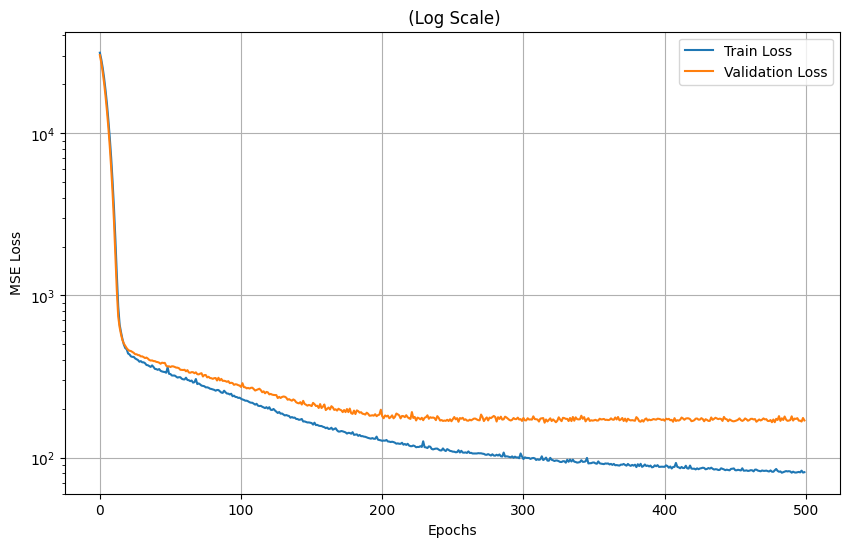

In [112]:
pipeline(dnn_16, epochs=epochs)

## DNN-30-8

In [113]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=33, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 1617.5409, Val Loss: 563.7244
Epoch [100/500], Train Loss: 1415.7285, Val Loss: 458.1569
Epoch [150/500], Train Loss: 1415.5661, Val Loss: 390.1742
Epoch [200/500], Train Loss: 1292.8071, Val Loss: 369.2924
Epoch [250/500], Train Loss: 1205.8390, Val Loss: 324.1499
Epoch [300/500], Train Loss: 1209.9497, Val Loss: 311.7235
Epoch [350/500], Train Loss: 1175.9459, Val Loss: 263.9396
Epoch [400/500], Train Loss: 1101.0880, Val Loss: 316.2077
Epoch [450/500], Train Loss: 1048.0093, Val Loss: 246.5874
Epoch [500/500], Train Loss: 1032.2532, Val Loss: 237.0330

========= Model Evaluation =========
Mean Absolute Error (MAE): 10.5209
Mean Squared Error (MSE): 197.9549
R^2 Score: 0.7322


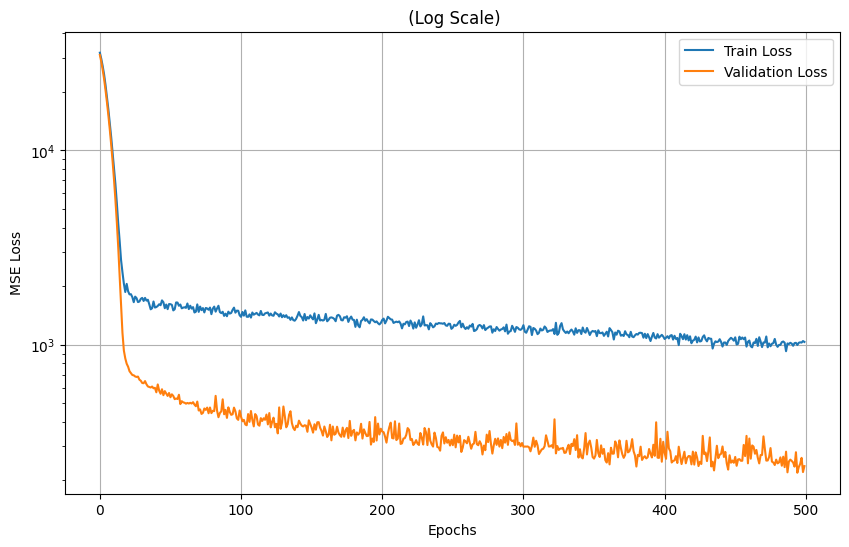

In [114]:
pipeline(dnn_30_8, epochs=epochs)

## DNN-30-16-8

In [115]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_16_8.model

Sequential(
  (0): Linear(in_features=33, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Sigmoid()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 1542.0293, Val Loss: 534.8391
Epoch [100/500], Train Loss: 1509.2048, Val Loss: 409.9354
Epoch [150/500], Train Loss: 1355.4520, Val Loss: 340.1026
Epoch [200/500], Train Loss: 1277.0273, Val Loss: 304.9641
Epoch [250/500], Train Loss: 1261.5751, Val Loss: 295.8417
Epoch [300/500], Train Loss: 1161.0725, Val Loss: 283.0623
Epoch [350/500], Train Loss: 1167.5008, Val Loss: 256.6760
Epoch [400/500], Train Loss: 1137.9067, Val Loss: 249.6319
Epoch [450/500], Train Loss: 994.0673, Val Loss: 229.7739
Epoch [500/500], Train Loss: 1018.7576, Val Loss: 234.4232

========= Model Evaluation =========
Mean Absolute Error (MAE): 10.5915
Mean Squared Error (MSE): 198.4733
R^2 Score: 0.7315


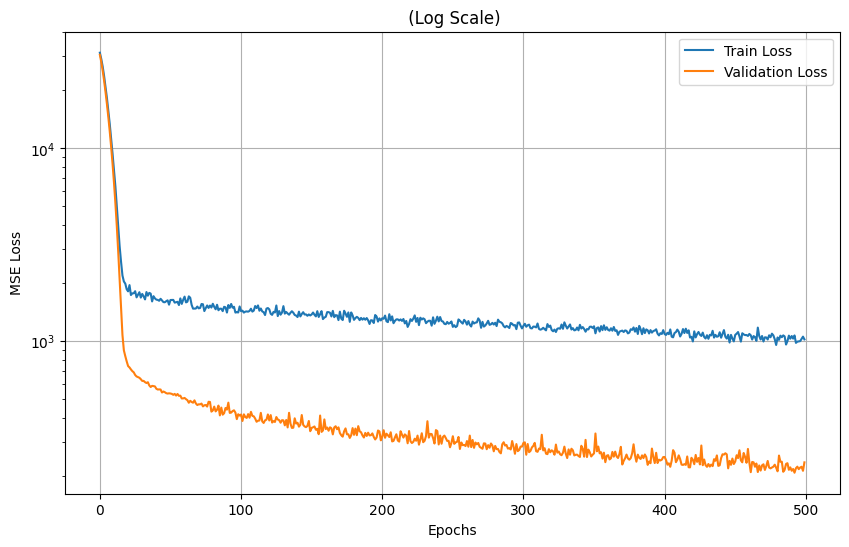

In [116]:
pipeline(dnn_30_16_8, epochs=epochs)

## DNN-30-16-8-4

In [117]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_16_8_4.model

Sequential(
  (0): Linear(in_features=33, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Sigmoid()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=8, out_features=4, bias=True)
  (11): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): Sigmoid()
  (13): Dropout(p=0.3, inplace=False)
  (14): Linear(in_features=4, out_features=1, bias=True)
)

In [ ]:
pipeline(dnn_30_16_8_4, epochs=epochs)

Epoch [50/500], Train Loss: 2011.8170, Val Loss: 718.2411
Epoch [100/500], Train Loss: 1614.5202, Val Loss: 544.0559


## DNN-64-32-16-8

In [ ]:
dnn_64_32_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[128, 64, 32, 16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_64_32_16_8.model

Sequential(
  (0): Linear(in_features=33, out_features=128, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Sigmoid()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=32, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 772.8919, Val Loss: 375.2062
Epoch [100/500], Train Loss: 685.8041, Val Loss: 308.3991
Epoch [150/500], Train Loss: 646.8867, Val Loss: 249.2794
Epoch [200/500], Train Loss: 662.8930, Val Loss: 257.7140
Epoch [250/500], Train Loss: 615.8708, Val Loss: 253.6325
Epoch [300/500], Train Loss: 567.6299, Val Loss: 197.7887
Epoch [350/500], Train Loss: 556.3722, Val Loss: 228.1758
Epoch [400/500], Train Loss: 593.3018, Val Loss: 213.3022
Epoch [450/500], Train Loss: 539.0468, Val Loss: 183.6047
Epoch [500/500], Train Loss: 526.6477, Val Loss: 173.1962

========= Model Evaluation =========
Mean Absolute Error (MAE): 9.4506
Mean Squared Error (MSE): 161.7996
R^2 Score: 0.7811


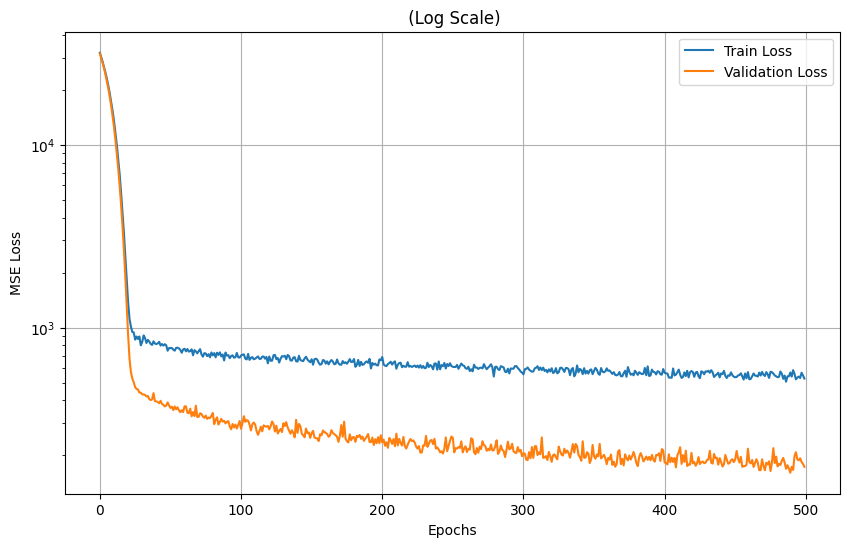

In [ ]:
pipeline(dnn_64_32_16_8, epochs=epochs)